## 1. Imports and setup

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import json
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from implied_volatility_diffusion import (
    SurfaceNormalizer,
    UnifiedGrid,
    load_config,
    merge_config,
    merge_config_files,
)
from implied_volatility_diffusion.data.historical_data_smoothing_interpolation import (
    load_cleaned_data,
)
from implied_volatility_diffusion.data.historical_sabr_interpolation import (
    build_historical_sabr_surface,
)
from implied_volatility_diffusion.synthetic.heston import (
    implied_vol_surfaces_heston_sequential_lhs,
    load_heston_iv_surface_config,
)
from implied_volatility_diffusion.synthetic.sabr import (
    implied_vol_surfaces_sabr_sequential_lhs,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "axes.grid": False})

In [7]:
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CFG_DIR = REPO_ROOT / "config"
DATA_DIR = REPO_ROOT / "data"
PROCESSED_PARQUET = DATA_DIR / "processed" / "processed.parquet"

OUT_ROOT = DATA_DIR / "processed" / "forecasting_dataset"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

In [8]:
GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")
K_AXIS = GRID.log_moneyness
TAU_AXIS = GRID.tau
KK, TT = GRID.meshgrid()
print(
    "unified grid:",
    GRID.shape,
    "  k in",
    (float(K_AXIS[0]), float(K_AXIS[-1])),
    "  tau in",
    (float(TAU_AXIS[0]), float(TAU_AXIS[-1])),
)

SAMPLE_DATE = pd.Timestamp("2021-06-17")
HIST_DATE_FROM = pd.Timestamp("2019-01-01")
HIST_DATE_TO = pd.Timestamp("2023-12-31")
SEED = 42

# Risk-neutral assumptions used for the historic SABR calibration
HIST_R = 0.03
HIST_Q = 0.0
HIST_BETA = 0.5

unified grid: (41, 40)   k in (-0.5, 0.5000000000000003)   tau in (0.05, 2.000000000000001)


In [9]:
# trainig/validation split
HIST_TRAIN_FRAC = 0.70
SYNTH_TRAIN_FRAC = 0.80

## Historic data pipeline

In [10]:
t0 = time.perf_counter()
df = load_cleaned_data(PROCESSED_PARQUET)
print(f"loaded {len(df):,} rows in {time.perf_counter() - t0:.1f}s")
print("quote date span:", df["quote_date"].min().date(), "->", df["quote_date"].max().date())

loaded 15,409,923 rows in 7.0s
quote date span: 2019-01-02 -> 2023-12-29


In [11]:
unique_dates = pd.DatetimeIndex(np.sort(df["quote_date"].dropna().unique()))
in_range = (unique_dates >= HIST_DATE_FROM) & (unique_dates <= HIST_DATE_TO)
window_dates = unique_dates[in_range]
print(f"historic window: {len(window_dates)} days from {window_dates[0].date()} to {window_dates[-1].date()}")

historic window: 1248 days from 2019-01-02 to 2023-12-29


In [12]:
hist_results = {}
surfaces_collected = []
dates_collected = []
quote_counts_collected = []
n_expiries_collected = []
spot_collected = []
skipped_dates = []

t0 = time.perf_counter()
n_days = int(len(window_dates))
for i, d in enumerate(window_dates):
    day_df = df[df["quote_date"] == d]
    try:
        res = build_historical_sabr_surface(
            day_df,
            k_grid=K_AXIS,
            tau_grid=TAU_AXIS,
            r=HIST_R,
            q=HIST_Q,
            beta=HIST_BETA,
        )
    except Exception as exc:
        skipped_dates.append((d, f"{type(exc).__name__}: {exc}"))
        continue
    surf = res.surface
    if not np.all(np.isfinite(surf)):
        skipped_dates.append((d, "non-finite cells in calibrated surface"))
        continue

    hist_results[d] = res
    surfaces_collected.append(surf)
    dates_collected.append(d)
    quote_counts_collected.append(len(res.day_sub))
    n_expiries_collected.append(int(res.expiry_taus.size))
    spot_collected.append(float(res.spot))

    if (i + 1) % 50 == 0 or (i + 1) == n_days:
        rate = (i + 1) / max(time.perf_counter() - t0, 1e-9)
        eta = (n_days - (i + 1)) / max(rate, 1e-9)
        print(
            f"  [{i + 1:>4d}/{n_days}] kept={len(surfaces_collected):>4d}  "
            f"skipped={len(skipped_dates):>3d}  rate={rate:.1f} d/s  eta={eta:.0f}s"
        )


hist_stack = np.stack(surfaces_collected, axis=0)
hist_dates = pd.DatetimeIndex(dates_collected)
hist_quote_counts = np.asarray(quote_counts_collected, dtype=int)
hist_n_expiries = np.asarray(n_expiries_collected, dtype=int)
hist_spot = np.asarray(spot_collected, dtype=float)
hist_sample = hist_results[SAMPLE_DATE]
print(
    f"historic SABR pipeline: kept {hist_stack.shape[0]}/{n_days} days "
    f"(skipped {len(skipped_dates)}) in {time.perf_counter() - t0:.1f}s"
)

  [  50/1248] kept=  50  skipped=  0  rate=4.4 d/s  eta=270s
  [ 100/1248] kept= 100  skipped=  0  rate=4.7 d/s  eta=246s
  [ 150/1248] kept= 150  skipped=  0  rate=4.8 d/s  eta=231s
  [ 200/1248] kept= 200  skipped=  0  rate=4.8 d/s  eta=219s
  [ 250/1248] kept= 250  skipped=  0  rate=4.7 d/s  eta=211s
  [ 300/1248] kept= 300  skipped=  0  rate=4.7 d/s  eta=204s
  [ 350/1248] kept= 350  skipped=  0  rate=4.7 d/s  eta=191s
  [ 400/1248] kept= 400  skipped=  0  rate=4.7 d/s  eta=179s
  [ 450/1248] kept= 450  skipped=  0  rate=4.8 d/s  eta=167s
  [ 500/1248] kept= 500  skipped=  0  rate=4.8 d/s  eta=155s
  [ 550/1248] kept= 550  skipped=  0  rate=4.8 d/s  eta=145s
  [ 600/1248] kept= 600  skipped=  0  rate=4.8 d/s  eta=135s
  [ 650/1248] kept= 650  skipped=  0  rate=4.8 d/s  eta=125s
  [ 700/1248] kept= 700  skipped=  0  rate=4.7 d/s  eta=116s
  [ 750/1248] kept= 750  skipped=  0  rate=4.7 d/s  eta=107s
  [ 800/1248] kept= 800  skipped=  0  rate=4.6 d/s  eta=97s
  [ 850/1248] kept= 850  

## Synthetic Heston-COS surface - Unified grid

In [15]:
HESTON_PATHS = 4
HESTON_STEPS = 120

heston_cfg_raw = load_heston_iv_surface_config(CFG_DIR)
heston_cfg = GRID.with_config(heston_cfg_raw)

t0 = time.perf_counter()
heston_params, heston_m, heston_tau, heston_iv_native = implied_vol_surfaces_heston_sequential_lhs(
    heston_cfg,
    n_samples=HESTON_PATHS,
    n_batches=1,
    n_steps=HESTON_STEPS,
    seed=SEED,
)
print(f"Heston sequential LHS: {heston_iv_native.shape} in {time.perf_counter() - t0:.1f}s")

Heston sequential LHS: (4, 120, 41, 40) in 513.7s


In [16]:
HESTON_REGIMES: dict[str, Path] = {
    "skew": CFG_DIR / "heston_goal_skew.yaml",
    "smile": CFG_DIR / "heston_goal_smile.yaml",
    "high_vol": CFG_DIR / "heston_goal_high_vol.yaml",
    "low_vol": CFG_DIR / "heston_goal_low_vol.yaml",
}
HESTON_REGIME_PATHS = 4

heston_regime_stacks: list[np.ndarray] = [heston_iv_native]
heston_regime_labels: list[str] = ["base"] * heston_iv_native.shape[0]
heston_regime_param_blocks: list[np.ndarray] = [heston_params]

for r_idx, (regime_name, regime_yaml) in enumerate(HESTON_REGIMES.items()):
    overrides = load_config(regime_yaml)
    regime_raw = merge_config(heston_cfg_raw, overrides)
    regime_cfg = GRID.with_config(regime_raw)
    t_reg = time.perf_counter()
    r_params, _, _, r_iv = implied_vol_surfaces_heston_sequential_lhs(
        regime_cfg,
        n_samples=HESTON_REGIME_PATHS,
        n_batches=1,
        n_steps=HESTON_STEPS,
        seed=SEED + 11 + r_idx,
    )
    r_finite_mask = np.isfinite(r_iv).all(axis=(-1, -2)).all(axis=-1)
    heston_regime_stacks.append(r_iv)
    heston_regime_labels.extend([regime_name] * r_iv.shape[0])
    heston_regime_param_blocks.append(r_params)
    print(f"  Heston regime '{regime_name}': {r_iv.shape}  in {time.perf_counter() - t_reg:.1f}s")

heston_stack = np.concatenate(heston_regime_stacks, axis=0)
heston_params = np.concatenate(heston_regime_param_blocks, axis=0)
heston_regime_array = np.asarray(heston_regime_labels)
print(f"Heston pooled stack: {heston_stack.shape}  (regimes: base + {len(HESTON_REGIMES)} presets)")
heston_sample = heston_stack[0, 0]
heston_raw_sample = heston_iv_native[0, 0]

  Heston regime 'skew': (4, 120, 41, 40)  in 503.3s
  Heston regime 'smile': (4, 120, 41, 40)  in 503.7s
  Heston regime 'high_vol': (4, 120, 41, 40)  in 520.6s
  Heston regime 'low_vol': (4, 120, 41, 40)  in 485.0s
Heston pooled stack: (20, 120, 41, 40)  (regimes: base + 4 presets)


## Synthetic SABR surface - Unified grid

In [17]:
SABR_PATHS = 16
SABR_STEPS = 120

sabr_cfg_raw = merge_config_files(CFG_DIR / "sabr_iv_surface.yaml")
sabr_cfg = GRID.with_config(sabr_cfg_raw)

t0 = time.perf_counter()
sabr_params, sabr_m, sabr_tau, sabr_iv_native = implied_vol_surfaces_sabr_sequential_lhs(
    sabr_cfg,
    n_samples=SABR_PATHS,
    n_batches=1,
    n_steps=SABR_STEPS,
    seed=SEED,
)
SABR_REGIMES: dict[str, dict] = {
    "skew": {"sabr_ranges": {"alpha": [0.10, 0.40], "rho": [-0.95, -0.55], "nu": [0.40, 0.95]}},
    "smile": {"sabr_ranges": {"alpha": [0.15, 0.45], "rho": [-0.15, 0.15], "nu": [0.50, 1.10]}},
    "high_vol": {"sabr_ranges": {"alpha": [0.30, 0.60], "rho": [-0.60, 0.10], "nu": [0.40, 1.10]}},
    "low_vol": {"sabr_ranges": {"alpha": [0.03, 0.12], "rho": [-0.50, 0.10], "nu": [0.05, 0.40]}},
}
SABR_REGIME_PATHS = 8

sabr_regime_stacks: list[np.ndarray] = [sabr_iv_native]
sabr_regime_labels: list[str] = ["base"] * sabr_iv_native.shape[0]
sabr_regime_param_blocks: list[np.ndarray] = [sabr_params]

for r_idx, (regime_name, overrides) in enumerate(SABR_REGIMES.items()):
    regime_raw = merge_config(sabr_cfg_raw, overrides)
    regime_cfg = GRID.with_config(regime_raw)
    t_reg = time.perf_counter()
    r_params, _, _, r_iv = implied_vol_surfaces_sabr_sequential_lhs(
        regime_cfg,
        n_samples=SABR_REGIME_PATHS,
        n_batches=1,
        n_steps=SABR_STEPS,
        seed=SEED + 21 + r_idx,
    )
    r_finite_mask = np.isfinite(r_iv).all(axis=(-1, -2)).all(axis=-1)
    sabr_regime_stacks.append(r_iv)
    sabr_regime_labels.extend([regime_name] * r_iv.shape[0])
    sabr_regime_param_blocks.append(r_params)
    print(f"  SABR regime '{regime_name}': {r_iv.shape}  in {time.perf_counter() - t_reg:.1f}s")

sabr_stack = np.concatenate(sabr_regime_stacks, axis=0)
sabr_params = np.concatenate(sabr_regime_param_blocks, axis=0)
sabr_regime_array = np.asarray(sabr_regime_labels)
print(f"SABR pooled stack: {sabr_stack.shape}  (regimes: base + {len(SABR_REGIMES)} presets)")
sabr_sample = sabr_stack[0, 0]
sabr_raw_sample = sabr_iv_native[0, 0]

  SABR regime 'skew': (8, 120, 41, 40)  in 7.9s
  SABR regime 'smile': (8, 120, 41, 40)  in 7.9s
  SABR regime 'high_vol': (8, 120, 41, 40)  in 7.9s
  SABR regime 'low_vol': (8, 120, 41, 40)  in 7.8s
SABR pooled stack: (48, 120, 41, 40)  (regimes: base + 4 presets)


## Fit per-source normalizers

In [18]:
heston_flat = heston_stack.reshape(-1, *GRID.shape)
sabr_flat = sabr_stack.reshape(-1, *GRID.shape)

_hist_n_pairs = int(hist_stack.shape[0]) - 1
_hist_n_train_pairs = max(1, min(_hist_n_pairs - 1, int(round(HIST_TRAIN_FRAC * _hist_n_pairs))))
hist_train_surfaces = hist_stack[: _hist_n_train_pairs + 1]


# Heston / SABR: deterministic path permutation, first SYNTH_TRAIN_FRAC paths -> training.
def _train_path_ids(n_paths: int, train_frac: float, seed: int) -> np.ndarray:
    n_train = max(1, min(n_paths - 1, int(round(train_frac * n_paths))))
    return np.sort(np.random.default_rng(seed).permutation(n_paths)[:n_train])


heston_train_path_ids = _train_path_ids(heston_stack.shape[0], SYNTH_TRAIN_FRAC, SEED + 100)
sabr_train_path_ids = _train_path_ids(sabr_stack.shape[0], SYNTH_TRAIN_FRAC, SEED + 200)

heston_train_surfaces = heston_stack[heston_train_path_ids].reshape(-1, *GRID.shape)
sabr_train_surfaces = sabr_stack[sabr_train_path_ids].reshape(-1, *GRID.shape)

normalizers: dict[str, SurfaceNormalizer] = {}

# Fit one normalizer per source on training data only
for name, train_data in [
    ("historic", hist_train_surfaces),
    ("heston", heston_train_surfaces),
    ("sabr", sabr_train_surfaces),
]:
    norm = SurfaceNormalizer(grid_shape=GRID.shape).fit(train_data)
    assert int(norm.count.min()) > 0, f"{name}: pixel with zero training samples"
    normalizers[name] = norm
    print(
        f"{name:10s}  train surfaces={train_data.shape[0]:>5d}  "
        f"μ range=[{float(norm.mean.min()):+.4f}, {float(norm.mean.max()):+.4f}]  "
        f"σ* range=[{float(norm.std.min()):.4f}, {float(norm.std.max()):.4f}]"
    )

source_labels = {0: "historic", 1: "heston", 2: "sabr"}

historic    train surfaces=  874  μ range=[-1.9929, -0.2655]  σ* range=[0.1319, 0.4467]
heston      train surfaces= 1920  μ range=[-1.7837, -0.8902]  σ* range=[0.2104, 2.3318]
sabr        train surfaces= 4560  μ range=[-4.1303, -2.6111]  σ* range=[0.6909, 0.7940]


In [19]:
hist_z = normalizers["historic"].transform(hist_stack)
heston_z = normalizers["heston"].transform(heston_flat).reshape(heston_stack.shape)
sabr_z = normalizers["sabr"].transform(sabr_flat).reshape(sabr_stack.shape)

hist_denorm = normalizers["historic"].inverse_transform(hist_z)
heston_denorm = normalizers["heston"].inverse_transform(heston_z.reshape(-1, *GRID.shape)).reshape(heston_stack.shape)
sabr_denorm = normalizers["sabr"].inverse_transform(sabr_z.reshape(-1, *GRID.shape)).reshape(sabr_stack.shape)

hist_idx_sample = int(np.where(hist_dates == SAMPLE_DATE)[0][0])
hist_sample_z = hist_z[hist_idx_sample]
hist_sample_denorm = hist_denorm[hist_idx_sample]
heston_sample_z = heston_z[0, 0]
heston_sample_denorm = heston_denorm[0, 0]
sabr_sample_z = sabr_z[0, 0]
sabr_sample_denorm = sabr_denorm[0, 0]

# Roundtrip fidelity
for name, a, b in [
    ("historic", hist_stack, hist_denorm),
    ("heston", heston_stack, heston_denorm),
    ("sabr", sabr_stack, sabr_denorm),
]:
    diff = np.abs(a - b)
    print(f"roundtrip |σ − denorm(norm(σ))|  [{name:8s}]  max = {np.nanmax(diff):.2e}   mean = {np.nanmean(diff):.2e}")

print()
for name, z_arr in [("historic", hist_z), ("heston", heston_z), ("sabr", sabr_z)]:
    flat = z_arr.reshape(-1, *GRID.shape)
    print(f"  {name:10s}  z-score  mean={flat.mean():+.4f}  std={flat.std():.4f}")

roundtrip |σ − denorm(norm(σ))|  [historic]  max = 4.44e-16   mean = 8.54e-18
roundtrip |σ − denorm(norm(σ))|  [heston  ]  max = 2.22e-16   mean = 8.11e-18
roundtrip |σ − denorm(norm(σ))|  [sabr    ]  max = 6.94e-17   mean = 5.26e-18

  historic    z-score  mean=-0.0677  std=0.9284
  heston      z-score  mean=+0.0929  std=0.9433
  sabr        z-score  mean=-0.0226  std=0.9994


## Save with sequential layout

In [20]:
hist_dir = OUT_ROOT / "historical"
hist_dir.mkdir(parents=True, exist_ok=True)
np.save(hist_dir / "surfaces.npy", hist_stack)
np.save(hist_dir / "surfaces_normalized.npy", hist_z)
np.save(hist_dir / "dates.npy", np.asarray(hist_dates.values, dtype="datetime64[D]"))
np.save(hist_dir / "quote_counts.npy", hist_quote_counts)
np.save(hist_dir / "n_expiries_calibrated.npy", hist_n_expiries)
np.save(hist_dir / "spot.npy", hist_spot)

hist_meta = {
    "source": "historical_spx",
    "dataset": str(PROCESSED_PARQUET.relative_to(REPO_ROOT)),
    "pipeline": [
        "filter_day_for_surface (k, tau, iv, vega bounds)",
        "group quotes by expiry",
        "per-expiry Hagan-SABR calibration of (alpha, rho, nu) with fixed beta",
        "evaluate SABR lognormal closed-form on the unified (k, tau) grid (interpolates across strikes, extrapolates across maturities via nearest-expiry slice)",
        "per-pixel log-sigma z-score normalization (source-specific normalizer, fit on training split only)",
    ],
    "sabr": {"beta": HIST_BETA, "r": HIST_R, "q": HIST_Q},
    "axis_order": ["day", "k", "tau"],
    "n_days": int(len(hist_dates)),
    "n_days_requested": int(len(window_dates)),
    "n_days_skipped": int(len(skipped_dates)),
    "date_range_requested": [str(HIST_DATE_FROM.date()), str(HIST_DATE_TO.date())],
    "sample_date": str(SAMPLE_DATE.date()),
    "sample_date_index": int(hist_idx_sample),
    "quote_date_range": [str(hist_dates[0].date()), str(hist_dates[-1].date())],
}
(hist_dir / "metadata.json").write_text(json.dumps(hist_meta, indent=2), encoding="utf-8")

904

In [21]:
heston_dir = OUT_ROOT / "heston"
heston_dir.mkdir(parents=True, exist_ok=True)
heston_dt = float((heston_cfg.get("sequential_ivs") or {}).get("dt", 1.0 / 252.0))
heston_step_sec = np.arange(HESTON_STEPS, dtype=float) * heston_dt * 365.0
np.save(heston_dir / "surfaces.npy", heston_stack)
np.save(heston_dir / "surfaces_normalized.npy", heston_z)
np.save(heston_dir / "params.npy", heston_params)
np.save(heston_dir / "step_days.npy", heston_step_sec)
np.save(heston_dir / "regime_labels.npy", heston_regime_array)

heston_meta = {
    "source": "synthetic_heston",
    "config": str((CFG_DIR / "heston_iv_surface.yaml").relative_to(REPO_ROOT)),
    "pipeline": [
        "Latin Hypercube sample of Heston (v0, rho, sigma_v, theta, kappa, r) with Feller clip",
        "Milstein integration of (S, v) under the risk-neutral measure",
        "Heston-COS European call prices on the unified (k, tau) grid at each step",
        "Jäckel implied-volatility inversion",
        "arbitrage guard (repair policy)",
        "per-pixel log-sigma z-score normalization (source-specific normalizer, fit on training split only)",
    ],
    "param_order": ["v0", "rho", "sigma", "theta", "kappa", "r"],
    "axis_order": ["path", "step", "k", "tau"],
    "n_paths": int(heston_stack.shape[0]),
    "n_paths_base": int(HESTON_PATHS),
    "n_paths_per_regime": int(HESTON_REGIME_PATHS),
    "n_steps": int(HESTON_STEPS),
    "dt_years": heston_dt,
    "seed": int(SEED),
    "regimes": ["base"] + list(HESTON_REGIMES.keys()),
    "regime_counts": {
        name: int(np.sum(heston_regime_array == name)) for name in (["base"] + list(HESTON_REGIMES.keys()))
    },
}
(heston_dir / "metadata.json").write_text(json.dumps(heston_meta, indent=2), encoding="utf-8")

1021

In [22]:
sabr_dir = OUT_ROOT / "sabr"
sabr_dir.mkdir(parents=True, exist_ok=True)
sabr_dt = float((sabr_cfg.get("sequential_ivs") or {}).get("dt", 1.0 / 252.0))
sabr_step_sec = np.arange(SABR_STEPS, dtype=float) * sabr_dt * 365.0
np.save(sabr_dir / "surfaces.npy", sabr_stack)
np.save(sabr_dir / "surfaces_normalized.npy", sabr_z)
np.save(sabr_dir / "params.npy", sabr_params)
np.save(sabr_dir / "step_days.npy", sabr_step_sec)
np.save(sabr_dir / "regime_labels.npy", sabr_regime_array)

sabr_meta = {
    "source": "synthetic_sabr",
    "config": str((CFG_DIR / "sabr_iv_surface.yaml").relative_to(REPO_ROOT)),
    "pipeline": [
        "Latin Hypercube sample of SABR (alpha, rho, nu) with fixed beta",
        "SABR SDE Euler step for (S, alpha) under the risk-neutral measure",
        "Hagan lognormal implied vol closed-form on the unified (k, tau) grid at each step",
        "arbitrage guard (repair policy)",
        "per-pixel log-sigma z-score normalization (source-specific normalizer, fit on training split only)",
    ],
    "param_order": ["alpha", "rho", "nu"],
    "beta": float((sabr_cfg.get("sabr") or {}).get("beta", 0.5)),
    "axis_order": ["path", "step", "k", "tau"],
    "n_paths": int(sabr_stack.shape[0]),
    "n_paths_base": int(SABR_PATHS),
    "n_paths_per_regime": int(SABR_REGIME_PATHS),
    "n_steps": int(SABR_STEPS),
    "dt_years": sabr_dt,
    "seed": int(SEED),
    "regimes": ["base"] + list(SABR_REGIMES.keys()),
    "regime_counts": {name: int(np.sum(sabr_regime_array == name)) for name in (["base"] + list(SABR_REGIMES.keys()))},
}
(sabr_dir / "metadata.json").write_text(json.dumps(sabr_meta, indent=2), encoding="utf-8")

941

In [23]:
normalizer_dir = OUT_ROOT / "normalizers"
normalizer_dir.mkdir(parents=True, exist_ok=True)
normalizer_paths = {}
for name, norm in normalizers.items():
    p = normalizer_dir / f"{name}.npz"
    norm.save(p)
    normalizer_paths[name] = p

manifest = {
    "sample_date": str(SAMPLE_DATE.date()),
    "grid": {
        "shape": list(GRID.shape),
        "config": str((CFG_DIR / "unified_iv_grid.yaml").relative_to(REPO_ROOT)),
    },
    "normalizers": {
        name: {
            "path": str(p.relative_to(REPO_ROOT)),
            "fit_on": "training",
            "n_train_surfaces": int(normalizers[name].count.max()),
        }
        for name, p in normalizer_paths.items()
    },
    "sources": {
        "historical": str(hist_dir.relative_to(REPO_ROOT)),
        "heston": str(heston_dir.relative_to(REPO_ROOT)),
        "sabr": str(sabr_dir.relative_to(REPO_ROOT)),
    },
}
(OUT_ROOT / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

828

## Build conditional pair

The diffusion U-Net is trained as a *conditional* next-day forecaster:
given the previous-day surface `S_t` it predicts the next-day surface
`S_{t+1}`.

- Historic SPX pairs are split chronologically 
- Heston / SABR pairs are split by path

In [24]:
# Historic: chronologica=
hist_curr_full = hist_stack[:-1]
hist_next_full = hist_stack[1:]
hist_curr_dates_full = hist_dates[:-1]
hist_next_dates_full = hist_dates[1:]
hist_pair_finite = np.isfinite(hist_curr_full).all(axis=(-1, -2)) & np.isfinite(hist_next_full).all(axis=(-1, -2))
hist_curr_pairs = hist_curr_full[hist_pair_finite]
hist_next_pairs = hist_next_full[hist_pair_finite]
hist_curr_dates_pairs = hist_curr_dates_full[hist_pair_finite]
hist_next_dates_pairs = hist_next_dates_full[hist_pair_finite]

n_hist_pairs = int(hist_curr_pairs.shape[0])
n_hist_train = int(round(HIST_TRAIN_FRAC * n_hist_pairs))
n_hist_train = max(1, min(n_hist_train, n_hist_pairs - 1))
hist_train_sel = np.zeros(n_hist_pairs, dtype=bool)
hist_train_sel[:n_hist_train] = True
hist_val_sel = ~hist_train_sel

print(
    f"historic pairs: {n_hist_pairs}  "
    f"-> train={int(hist_train_sel.sum())} "
    f"({hist_curr_dates_pairs[hist_train_sel][0].date()} → "
    f"{hist_next_dates_pairs[hist_train_sel][-1].date()}),  "
    f"val={int(hist_val_sel.sum())} "
    f"({hist_curr_dates_pairs[hist_val_sel][0].date()} → "
    f"{hist_next_dates_pairs[hist_val_sel][-1].date()})"
)

historic pairs: 1247  -> train=873 (2019-01-02 → 2022-07-07),  val=374 (2022-07-07 → 2023-12-29)


In [25]:
def _build_path_pairs(stack: np.ndarray, train_frac: float, train_path_seed: int) -> dict[str, np.ndarray]:
    """Pair consecutive simulation steps within each path and split by path.

    Returns a dict with train/val curr, next, path index, step index, and
    the deterministic permutation used to assign paths to splits.
    """
    P, S = int(stack.shape[0]), int(stack.shape[1])
    n_train_paths = max(1, min(P - 1, int(round(train_frac * P))))

    rng = np.random.default_rng(train_path_seed)
    perm = rng.permutation(P)
    train_paths = np.sort(perm[:n_train_paths])
    val_paths = np.sort(perm[n_train_paths:])

    def _slice(path_ids: np.ndarray) -> dict[str, np.ndarray]:
        sub = stack[path_ids]
        curr = sub[:, :-1].reshape(-1, *GRID.shape)
        nxt = sub[:, 1:].reshape(-1, *GRID.shape)
        path_idx = np.repeat(path_ids, S - 1)
        step_idx = np.tile(np.arange(S - 1, dtype=np.int64), len(path_ids))
        finite = np.isfinite(curr).all(axis=(-1, -2)) & np.isfinite(nxt).all(axis=(-1, -2))
        return {
            "curr": curr[finite].astype(np.float32),
            "next": nxt[finite].astype(np.float32),
            "path": path_idx[finite].astype(np.int64),
            "step": step_idx[finite].astype(np.int64),
        }

    train_pack = _slice(train_paths)
    val_pack = _slice(val_paths)
    return {
        "train_paths": train_paths,
        "val_paths": val_paths,
        "train": train_pack,
        "val": val_pack,
    }


heston_split = _build_path_pairs(heston_stack, SYNTH_TRAIN_FRAC, SEED + 100)
sabr_split = _build_path_pairs(sabr_stack, SYNTH_TRAIN_FRAC, SEED + 200)
print(
    f"heston paths: total={heston_stack.shape[0]}  "
    f"train_paths={heston_split['train_paths'].size}  val_paths={heston_split['val_paths'].size}  "
    f"train_pairs={heston_split['train']['curr'].shape[0]}  "
    f"val_pairs={heston_split['val']['curr'].shape[0]}"
)
print(
    f"sabr   paths: total={sabr_stack.shape[0]}  "
    f"train_paths={sabr_split['train_paths'].size}  val_paths={sabr_split['val_paths'].size}  "
    f"train_pairs={sabr_split['train']['curr'].shape[0]}  "
    f"val_pairs={sabr_split['val']['curr'].shape[0]}"
)

heston paths: total=20  train_paths=16  val_paths=4  train_pairs=1904  val_pairs=476
sabr   paths: total=48  train_paths=38  val_paths=10  train_pairs=4522  val_pairs=1190


Comnined dataset with historic and synthetic data

In [26]:
SRC_HIST, SRC_HESTON, SRC_SABR = 0, 1, 2

train_curr = np.concatenate(
    [
        hist_curr_pairs[hist_train_sel].astype(np.float32),
        heston_split["train"]["curr"],
        sabr_split["train"]["curr"],
    ],
    axis=0,
)
train_next = np.concatenate(
    [
        hist_next_pairs[hist_train_sel].astype(np.float32),
        heston_split["train"]["next"],
        sabr_split["train"]["next"],
    ],
    axis=0,
)
train_sources = np.concatenate(
    [
        np.full(int(hist_train_sel.sum()), SRC_HIST, dtype=np.int8),
        np.full(heston_split["train"]["curr"].shape[0], SRC_HESTON, dtype=np.int8),
        np.full(sabr_split["train"]["curr"].shape[0], SRC_SABR, dtype=np.int8),
    ]
)

val_curr = np.concatenate(
    [
        hist_curr_pairs[hist_val_sel].astype(np.float32),
        heston_split["val"]["curr"],
        sabr_split["val"]["curr"],
    ],
    axis=0,
)
val_next = np.concatenate(
    [
        hist_next_pairs[hist_val_sel].astype(np.float32),
        heston_split["val"]["next"],
        sabr_split["val"]["next"],
    ],
    axis=0,
)
val_sources = np.concatenate(
    [
        np.full(int(hist_val_sel.sum()), SRC_HIST, dtype=np.int8),
        np.full(heston_split["val"]["curr"].shape[0], SRC_HESTON, dtype=np.int8),
        np.full(sabr_split["val"]["curr"].shape[0], SRC_SABR, dtype=np.int8),
    ]
)
assert train_curr.shape == train_next.shape
assert val_curr.shape == val_next.shape
print(
    f"\npooled training pairs: {train_curr.shape[0]} "
    f"(hist={int((train_sources == SRC_HIST).sum())}, "
    f"heston={int((train_sources == SRC_HESTON).sum())}, "
    f"sabr={int((train_sources == SRC_SABR).sum())})"
)
print(
    f"pooled validation pairs: {val_curr.shape[0]} "
    f"(hist={int((val_sources == SRC_HIST).sum())}, "
    f"heston={int((val_sources == SRC_HESTON).sum())}, "
    f"sabr={int((val_sources == SRC_SABR).sum())})"
)


pooled training pairs: 7299 (hist=873, heston=1904, sabr=4522)
pooled validation pairs: 2040 (hist=374, heston=476, sabr=1190)


save modelling dataset

In [27]:
train_dir = OUT_ROOT / "training"
val_dir = OUT_ROOT / "validation"
train_dir.mkdir(parents=True, exist_ok=True)
val_dir.mkdir(parents=True, exist_ok=True)

np.save(train_dir / "pair_curr.npy", train_curr)
np.save(train_dir / "pair_next.npy", train_next)
np.save(train_dir / "pair_sources.npy", train_sources)

np.save(val_dir / "pair_curr.npy", val_curr)
np.save(val_dir / "pair_next.npy", val_next)
np.save(val_dir / "pair_sources.npy", val_sources)


np.save(
    train_dir / "historical_curr_dates.npy",
    np.asarray(hist_curr_dates_pairs[hist_train_sel].values, dtype="datetime64[D]"),
)
np.save(
    train_dir / "historical_next_dates.npy",
    np.asarray(hist_next_dates_pairs[hist_train_sel].values, dtype="datetime64[D]"),
)
np.save(
    val_dir / "historical_curr_dates.npy",
    np.asarray(hist_curr_dates_pairs[hist_val_sel].values, dtype="datetime64[D]"),
)
np.save(
    val_dir / "historical_next_dates.npy",
    np.asarray(hist_next_dates_pairs[hist_val_sel].values, dtype="datetime64[D]"),
)

# Synthetic per-pair (path, step) bookkeeping.
np.save(train_dir / "heston_path.npy", heston_split["train"]["path"])
np.save(train_dir / "heston_step.npy", heston_split["train"]["step"])
np.save(val_dir / "heston_path.npy", heston_split["val"]["path"])
np.save(val_dir / "heston_step.npy", heston_split["val"]["step"])
np.save(train_dir / "sabr_path.npy", sabr_split["train"]["path"])
np.save(train_dir / "sabr_step.npy", sabr_split["train"]["step"])
np.save(val_dir / "sabr_path.npy", sabr_split["val"]["path"])
np.save(val_dir / "sabr_step.npy", sabr_split["val"]["step"])

# Path-level split assignment per source (deterministic from SEED + offset).
np.save(train_dir / "heston_paths.npy", heston_split["train_paths"])
np.save(val_dir / "heston_paths.npy", heston_split["val_paths"])
np.save(train_dir / "sabr_paths.npy", sabr_split["train_paths"])
np.save(val_dir / "sabr_paths.npy", sabr_split["val_paths"])

# Per-source normalizers (each fit on training data only).
for name, norm in normalizers.items():
    norm.save(train_dir / f"normalizer_{name}.npz")
    norm.save(val_dir / f"normalizer_{name}.npz")

In [28]:
split_meta = {
    "task": "next_day_conditional_diffusion",
    "pair_layout": "(curr=S_t, next=S_{t+1}); model conditions on curr to predict next",
    "source_ids": {"historical": SRC_HIST, "heston": SRC_HESTON, "sabr": SRC_SABR},
    "train_frac": {
        "historical": float(HIST_TRAIN_FRAC),
        "heston": float(SYNTH_TRAIN_FRAC),
        "sabr": float(SYNTH_TRAIN_FRAC),
    },
    "split_strategy": {
        "historical": "chronological (first HIST_TRAIN_FRAC of dates -> train)",
        "heston": "by_path (deterministic permutation, seed=SEED+100)",
        "sabr": "by_path (deterministic permutation, seed=SEED+200)",
    },
    "counts": {
        "train": {
            "total": int(train_curr.shape[0]),
            "historical": int((train_sources == SRC_HIST).sum()),
            "heston": int((train_sources == SRC_HESTON).sum()),
            "sabr": int((train_sources == SRC_SABR).sum()),
        },
        "val": {
            "total": int(val_curr.shape[0]),
            "historical": int((val_sources == SRC_HIST).sum()),
            "heston": int((val_sources == SRC_HESTON).sum()),
            "sabr": int((val_sources == SRC_SABR).sum()),
        },
    },
    "historical_train_date_range": [
        str(hist_curr_dates_pairs[hist_train_sel][0].date()),
        str(hist_next_dates_pairs[hist_train_sel][-1].date()),
    ],
    "historical_val_date_range": [
        str(hist_curr_dates_pairs[hist_val_sel][0].date()),
        str(hist_next_dates_pairs[hist_val_sel][-1].date()),
    ],
    "normalizers": {name: f"normalizer_{name}.npz" for name in normalizers},
    "normalization_strategy": "per-source, fit on training split only",
}
(train_dir / "metadata.json").write_text(json.dumps({**split_meta, "split": "train"}, indent=2), encoding="utf-8")
(val_dir / "metadata.json").write_text(json.dumps({**split_meta, "split": "val"}, indent=2), encoding="utf-8")

manifest = json.loads((OUT_ROOT / "manifest.json").read_text())
manifest["splits"] = {
    "train": str(train_dir.relative_to(REPO_ROOT)),
    "val": str(val_dir.relative_to(REPO_ROOT)),
    **split_meta,
}
(OUT_ROOT / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(f"\nsaved fixed train pair stack -> {train_dir.relative_to(REPO_ROOT)}")
print(f"saved fixed val   pair stack -> {val_dir.relative_to(REPO_ROOT)}")


saved fixed train pair stack -> data/processed/forecasting_dataset/training
saved fixed val   pair stack -> data/processed/forecasting_dataset/validation


## Plot the sample for 2021-06-17

In [29]:
ELEV, AZIM = 28.0, -55.0
CMAP_IV = "turbo"
CMAP_Z = "coolwarm"

_SURFACE_KW = dict(linewidth=0.3, edgecolor="k", alpha=0.92, antialiased=True, rstride=1, cstride=1)


@dataclass
class SampleBundle:
    name: str
    title: str
    raw_mode: str
    raw_k: np.ndarray | None
    raw_tau: np.ndarray | None
    raw_iv: np.ndarray
    smoothed: np.ndarray
    normalized: np.ndarray
    denormalized: np.ndarray


hist_day_sub = hist_sample.day_sub
hist_sample_surface = hist_stack[hist_idx_sample]
bundles = [
    SampleBundle(
        name="historic",
        title=(f"Historic SPX — {SAMPLE_DATE.date()} "),
        raw_mode="scatter",
        raw_k=hist_day_sub["k"].to_numpy(dtype=float),
        raw_tau=hist_day_sub["tau"].to_numpy(dtype=float),
        raw_iv=hist_day_sub["iv"].to_numpy(dtype=float),
        smoothed=hist_sample_surface,
        normalized=hist_sample_z,
        denormalized=hist_sample_denorm,
    ),
    SampleBundle(
        name="heston",
        title="Synthetic Heston — path 0, step 0 (sample-date slot)",
        raw_mode="surface",
        raw_k=K_AXIS,
        raw_tau=TAU_AXIS,
        raw_iv=heston_raw_sample,
        smoothed=heston_sample,
        normalized=heston_sample_z,
        denormalized=heston_sample_denorm,
    ),
    SampleBundle(
        name="sabr",
        title="Synthetic SABR — path 0, step 0 (sample-date slot)",
        raw_mode="surface",
        raw_k=K_AXIS,
        raw_tau=TAU_AXIS,
        raw_iv=sabr_raw_sample,
        smoothed=sabr_sample,
        normalized=sabr_sample_z,
        denormalized=sabr_sample_denorm,
    ),
]


def _iv_scale(b: SampleBundle) -> tuple[float, float]:
    finite = b.smoothed[np.isfinite(b.smoothed)]
    lo, hi = float(np.min(finite)), float(np.max(finite))
    span = max(hi - lo, 1e-6)
    return max(0.0, lo - 0.10 * span), hi + 0.15 * span


def _z_scale(b: SampleBundle) -> tuple[float, float]:
    finite = b.normalized[np.isfinite(b.normalized)]
    if finite.size == 0:
        return -1.0, 1.0
    v = float(np.max(np.abs(finite)))
    return -v, v


def _label_3d(ax):
    ax.set_xlabel("k = log(K/S)", labelpad=8)
    ax.set_ylabel(r"$\tau$ (yrs)", labelpad=10)
    ax.set_xlim(float(K_AXIS[0]), float(K_AXIS[-1]))
    ax.set_ylim(float(TAU_AXIS[0]), float(TAU_AXIS[-1]))
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.tick_params(pad=2)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("0.85")
    ax.yaxis.pane.set_edgecolor("0.85")
    ax.zaxis.pane.set_edgecolor("0.85")


def _label_heat(ax):
    ax.set_xlabel(r"$\tau$ (yrs)")
    ax.set_ylabel("k = log(K/S)")
    ax.set_xlim(float(TAU_AXIS[0]), float(TAU_AXIS[-1]))
    ax.set_ylim(float(K_AXIS[0]), float(K_AXIS[-1]))


HEAT_EXTENT = (float(TAU_AXIS[0]), float(TAU_AXIS[-1]), float(K_AXIS[0]), float(K_AXIS[-1]))

In [30]:
print("sample bundles prepared:", [b.name for b in bundles])

sample bundles prepared: ['historic', 'heston', 'sabr']


###  Raw -> Smoothed -> Normalized

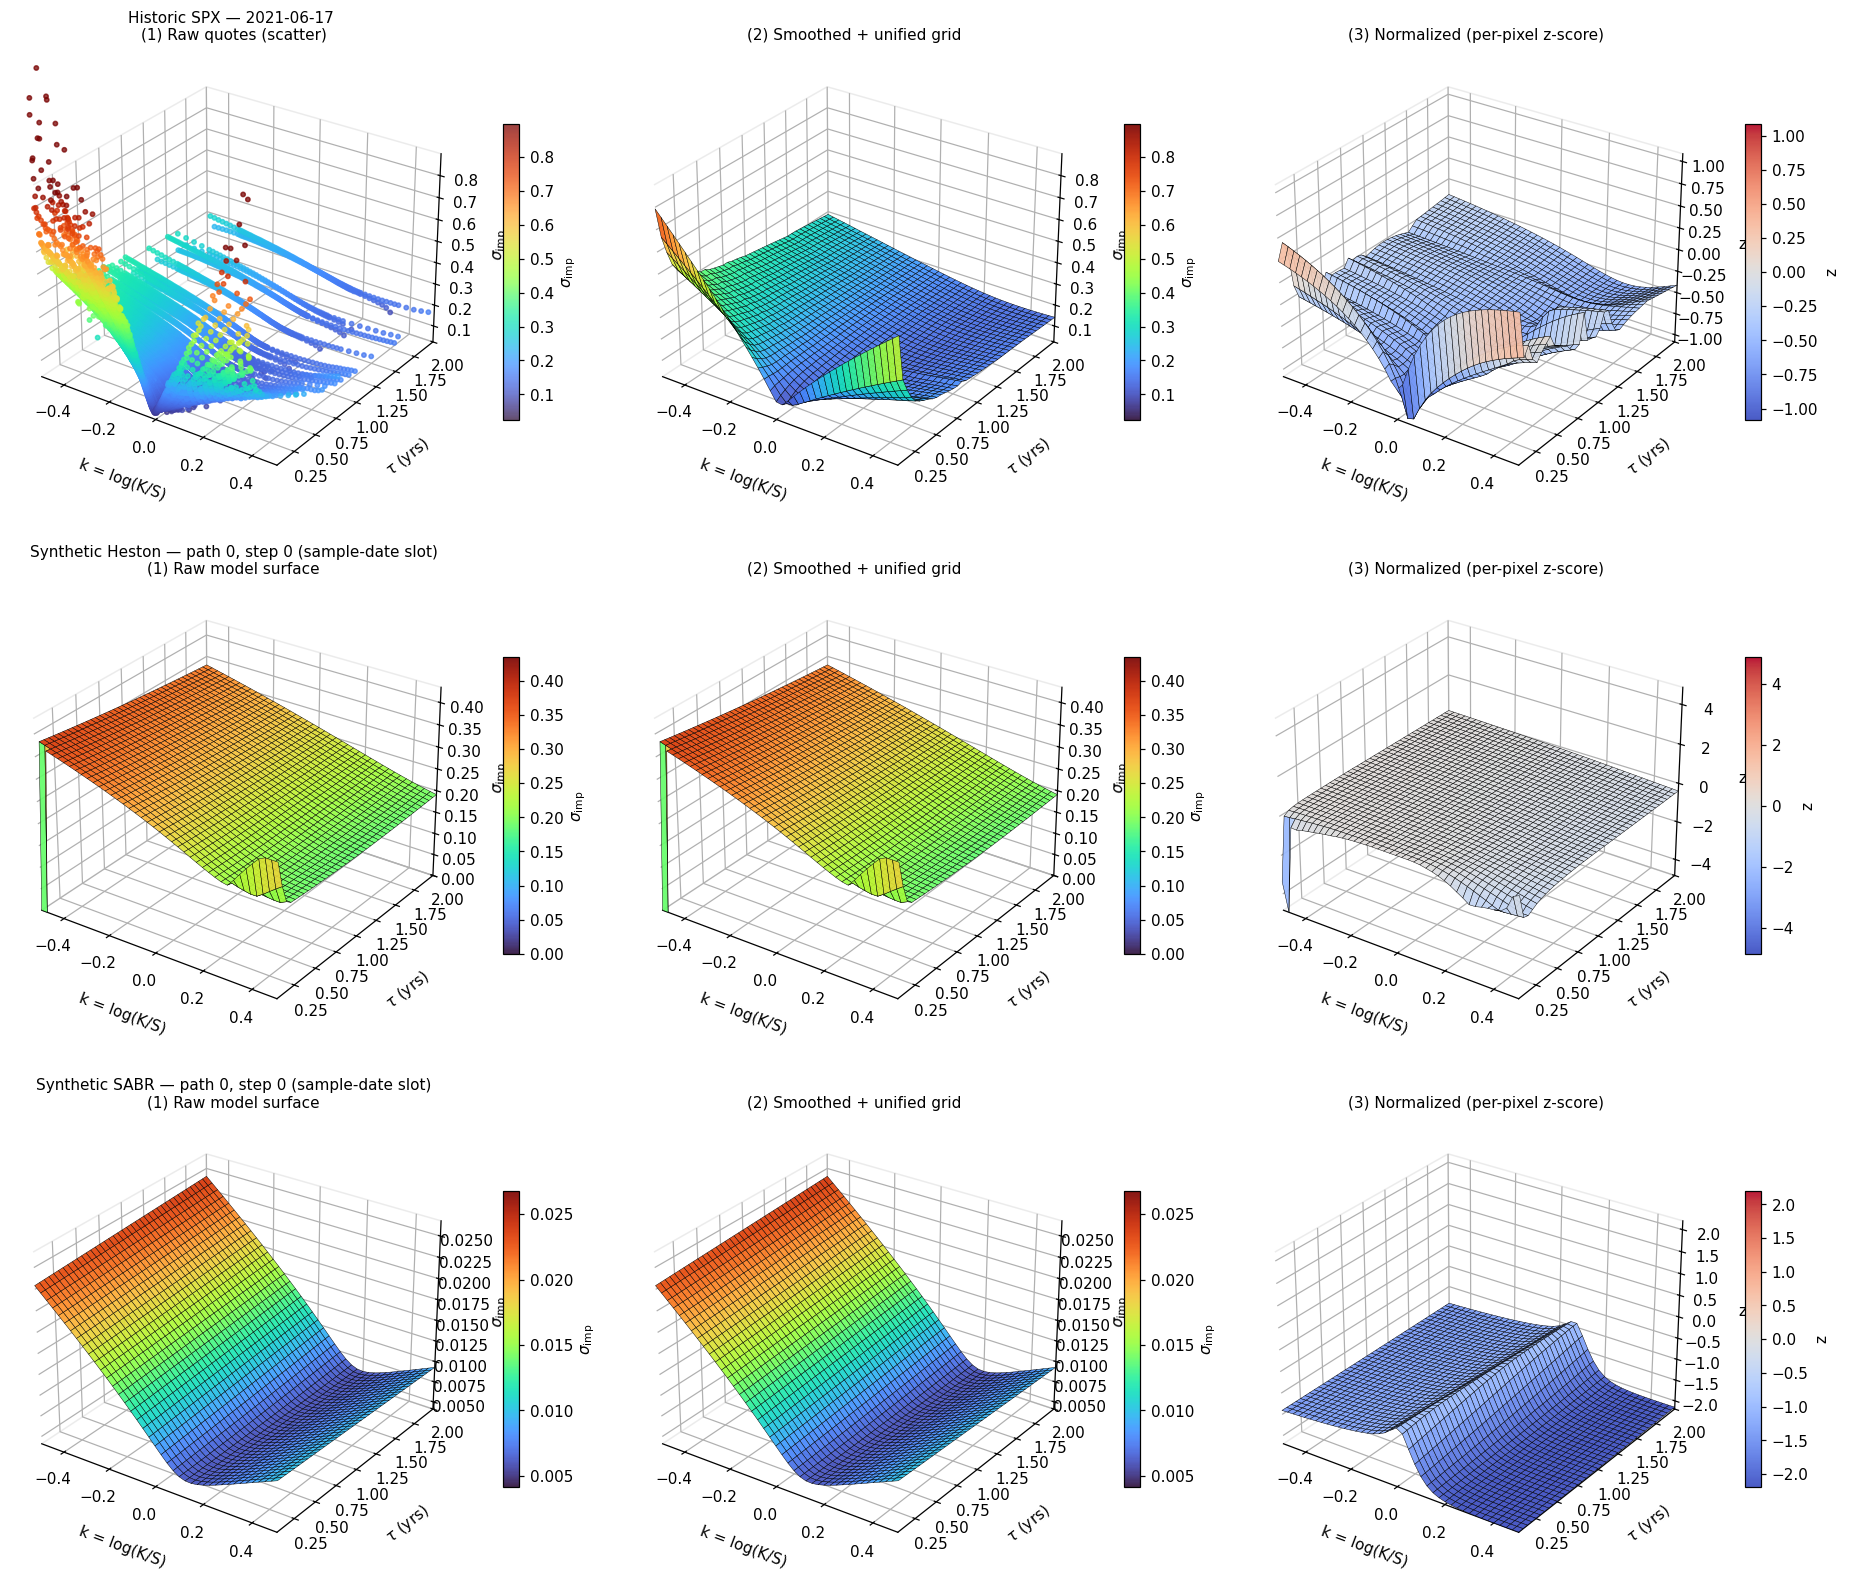

In [68]:
fig = plt.figure(figsize=(17, 5.2 * len(bundles)))

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax1 = fig.add_subplot(len(bundles), 3, row * 3 + 1, projection="3d")
    if b.raw_mode == "scatter":
        sc = ax1.scatter(
            b.raw_k,
            b.raw_tau,
            b.raw_iv,
            c=b.raw_iv,
            cmap=CMAP_IV,
            s=8,
            alpha=0.75,
            vmin=iv_vmin,
            vmax=iv_vmax,
        )
        fig.colorbar(sc, ax=ax1, shrink=0.55, pad=0.08, aspect=18, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw quotes (scatter)", fontsize=10)
    else:
        surf = ax1.plot_surface(KK, TT, b.raw_iv, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax, **_SURFACE_KW)
        fig.colorbar(surf, ax=ax1, shrink=0.55, pad=0.08, aspect=18, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw model surface", fontsize=10)
    _label_3d(ax1)
    ax1.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax1.set_zlim(iv_vmin, iv_vmax)

    ax2 = fig.add_subplot(len(bundles), 3, row * 3 + 2, projection="3d")
    surf = ax2.plot_surface(KK, TT, b.smoothed, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax, **_SURFACE_KW)
    fig.colorbar(surf, ax=ax2, shrink=0.55, pad=0.08, aspect=18, label=r"$\sigma_{\mathrm{imp}}$")
    ax2.set_title("(2) Smoothed + unified grid", fontsize=10)
    _label_3d(ax2)
    ax2.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax2.set_zlim(iv_vmin, iv_vmax)

    ax3 = fig.add_subplot(len(bundles), 3, row * 3 + 3, projection="3d")
    surf = ax3.plot_surface(KK, TT, b.normalized, cmap=CMAP_Z, vmin=z_vmin, vmax=z_vmax, **_SURFACE_KW)
    fig.colorbar(surf, ax=ax3, shrink=0.55, pad=0.08, aspect=18, label="z")
    ax3.set_title("(3) Normalized (per-pixel z-score)", fontsize=10)
    _label_3d(ax3)
    ax3.set_zlabel("z")
    ax3.set_zlim(z_vmin, z_vmax)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Heatmaps : Denormalized to Normalized

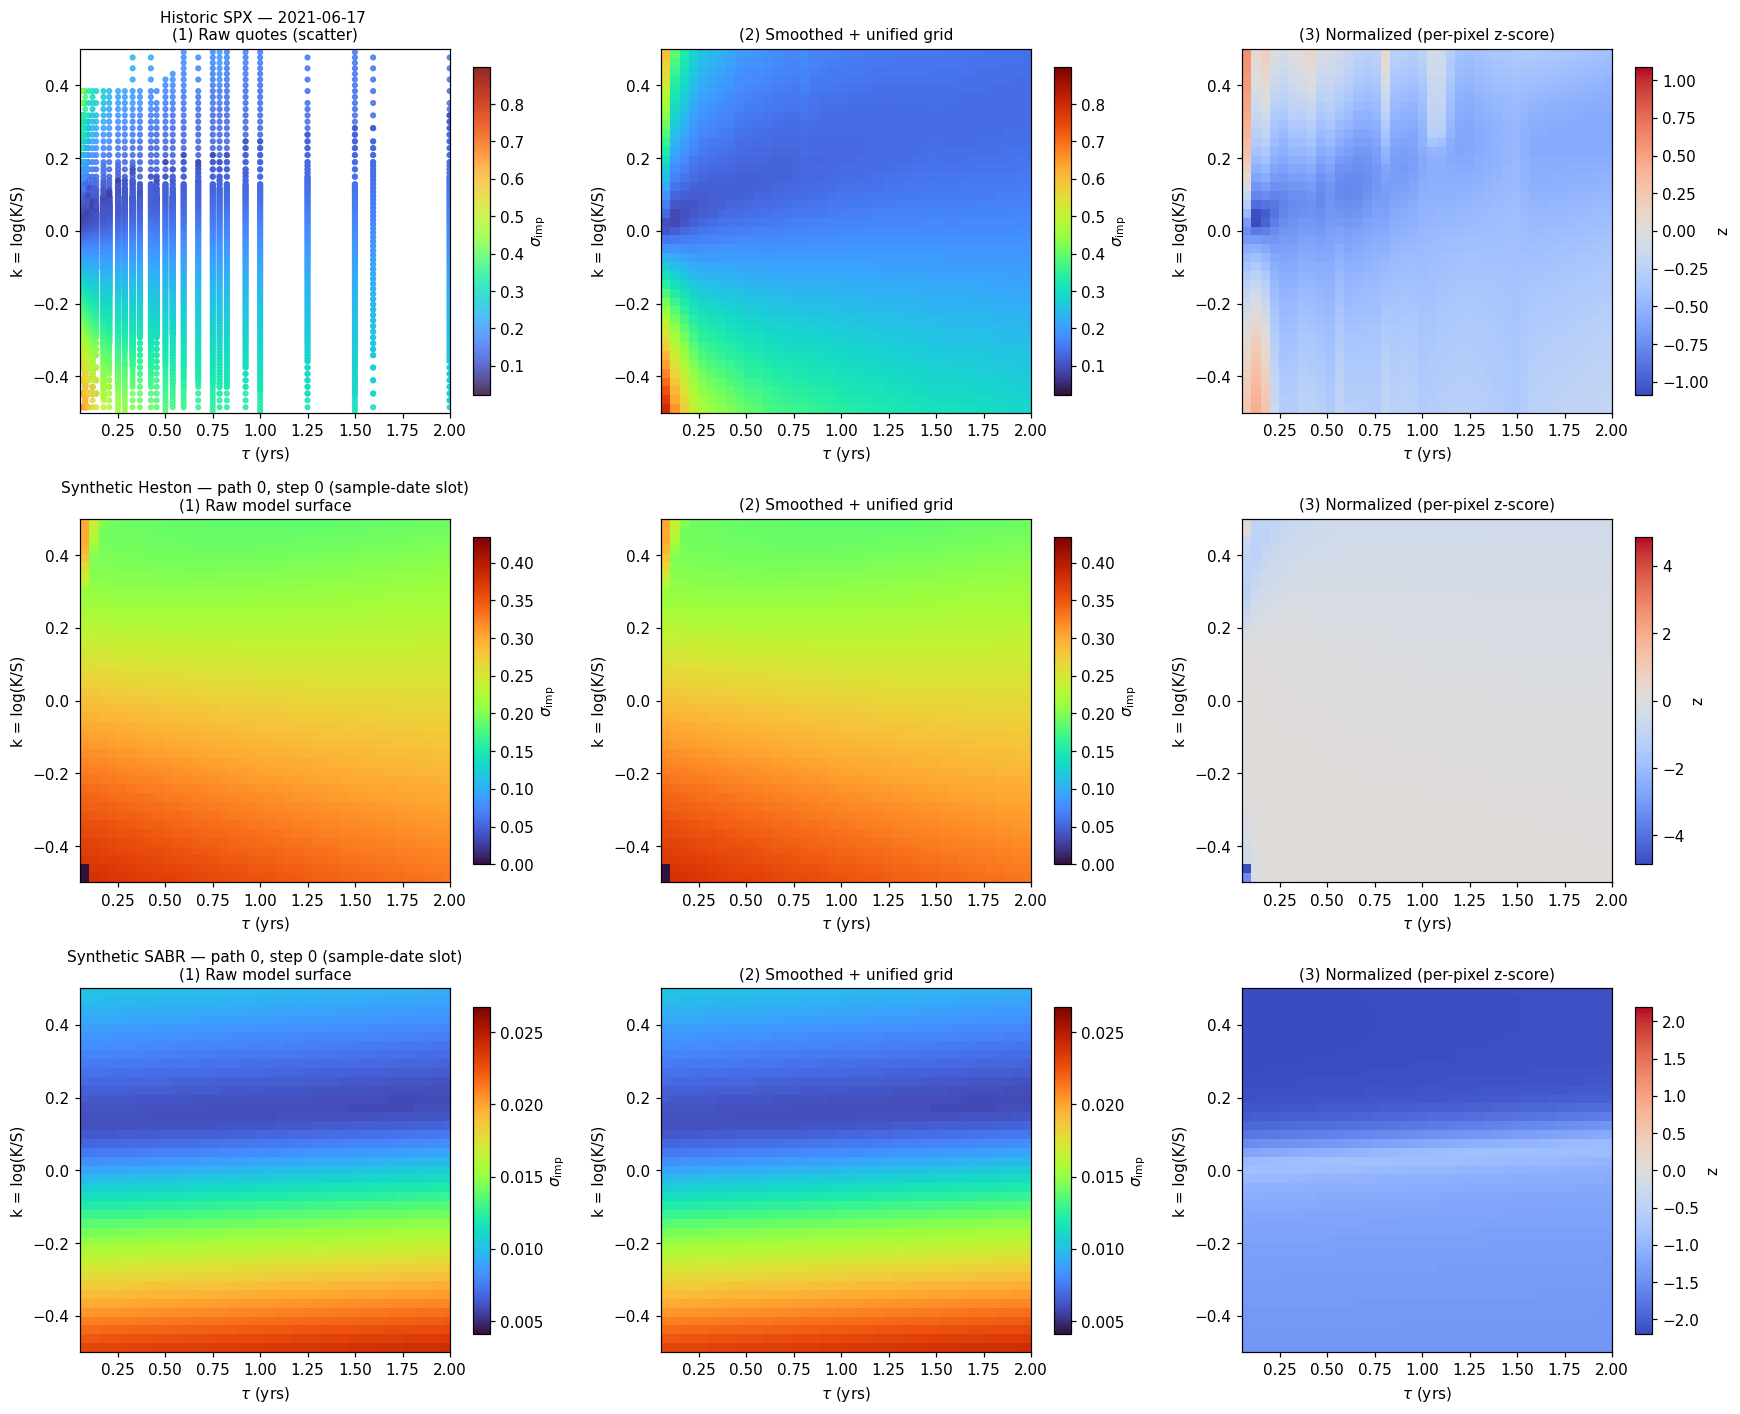

In [69]:
fig, axes = plt.subplots(len(bundles), 3, figsize=(16, 4.5 * len(bundles)))
if len(bundles) == 1:
    axes = np.atleast_2d(axes)

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax1 = axes[row, 0]
    if b.raw_mode == "scatter":
        sc = ax1.scatter(b.raw_tau, b.raw_k, c=b.raw_iv, cmap=CMAP_IV, s=9, alpha=0.85, vmin=iv_vmin, vmax=iv_vmax)
        fig.colorbar(sc, ax=ax1, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw quotes (scatter)", fontsize=10)
    else:
        im = ax1.imshow(
            b.raw_iv, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax
        )
        fig.colorbar(im, ax=ax1, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw model surface", fontsize=10)
    _label_heat(ax1)

    ax2 = axes[row, 1]
    im = ax2.imshow(
        b.smoothed, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax
    )
    fig.colorbar(im, ax=ax2, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
    ax2.set_title("(2) Smoothed + unified grid", fontsize=10)
    _label_heat(ax2)

    ax3 = axes[row, 2]
    im = ax3.imshow(
        b.normalized, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_Z, vmin=z_vmin, vmax=z_vmax
    )
    fig.colorbar(im, ax=ax3, shrink=0.9, label="z")
    ax3.set_title("(3) Normalized (per-pixel z-score)", fontsize=10)
    _label_heat(ax3)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Heatmaps : Normalized to Denormalized

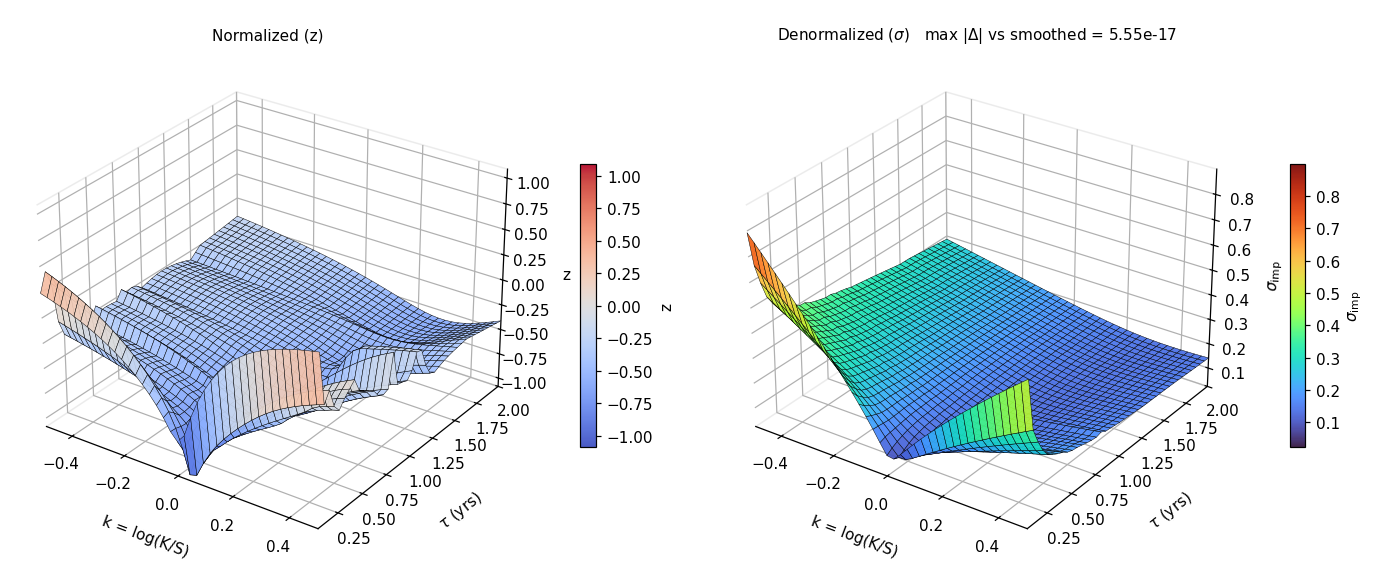

In [70]:
fig = plt.figure(figsize=(13, 5.2 * len(bundles)))

for row, b in enumerate(bundles):
    if b.name != "historic":
        continue
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax_left = fig.add_subplot(len(bundles), 2, row * 2 + 1, projection="3d")
    surf = ax_left.plot_surface(KK, TT, b.normalized, cmap=CMAP_Z, vmin=z_vmin, vmax=z_vmax, **_SURFACE_KW)
    fig.colorbar(surf, ax=ax_left, shrink=0.55, pad=0.08, aspect=18, label="z")
    ax_left.set_title("\nNormalized (z)", fontsize=10)
    _label_3d(ax_left)
    ax_left.set_zlabel("z")
    ax_left.set_zlim(z_vmin, z_vmax)

    ax_right = fig.add_subplot(len(bundles), 2, row * 2 + 2, projection="3d")
    surf = ax_right.plot_surface(KK, TT, b.denormalized, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax, **_SURFACE_KW)
    fig.colorbar(surf, ax=ax_right, shrink=0.55, pad=0.08, aspect=18, label=r"$\sigma_{\mathrm{imp}}$")
    diff = float(np.nanmax(np.abs(b.denormalized - b.smoothed)))
    ax_right.set_title(f"Denormalized ($\\sigma$)   max |Δ| vs smoothed = {diff:.2e}", fontsize=10)
    _label_3d(ax_right)
    ax_right.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax_right.set_zlim(iv_vmin, iv_vmax)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("pipeline_normalization_roundtrip_3d.pdf", bbox_inches="tight")
plt.show()

### Heatmaps

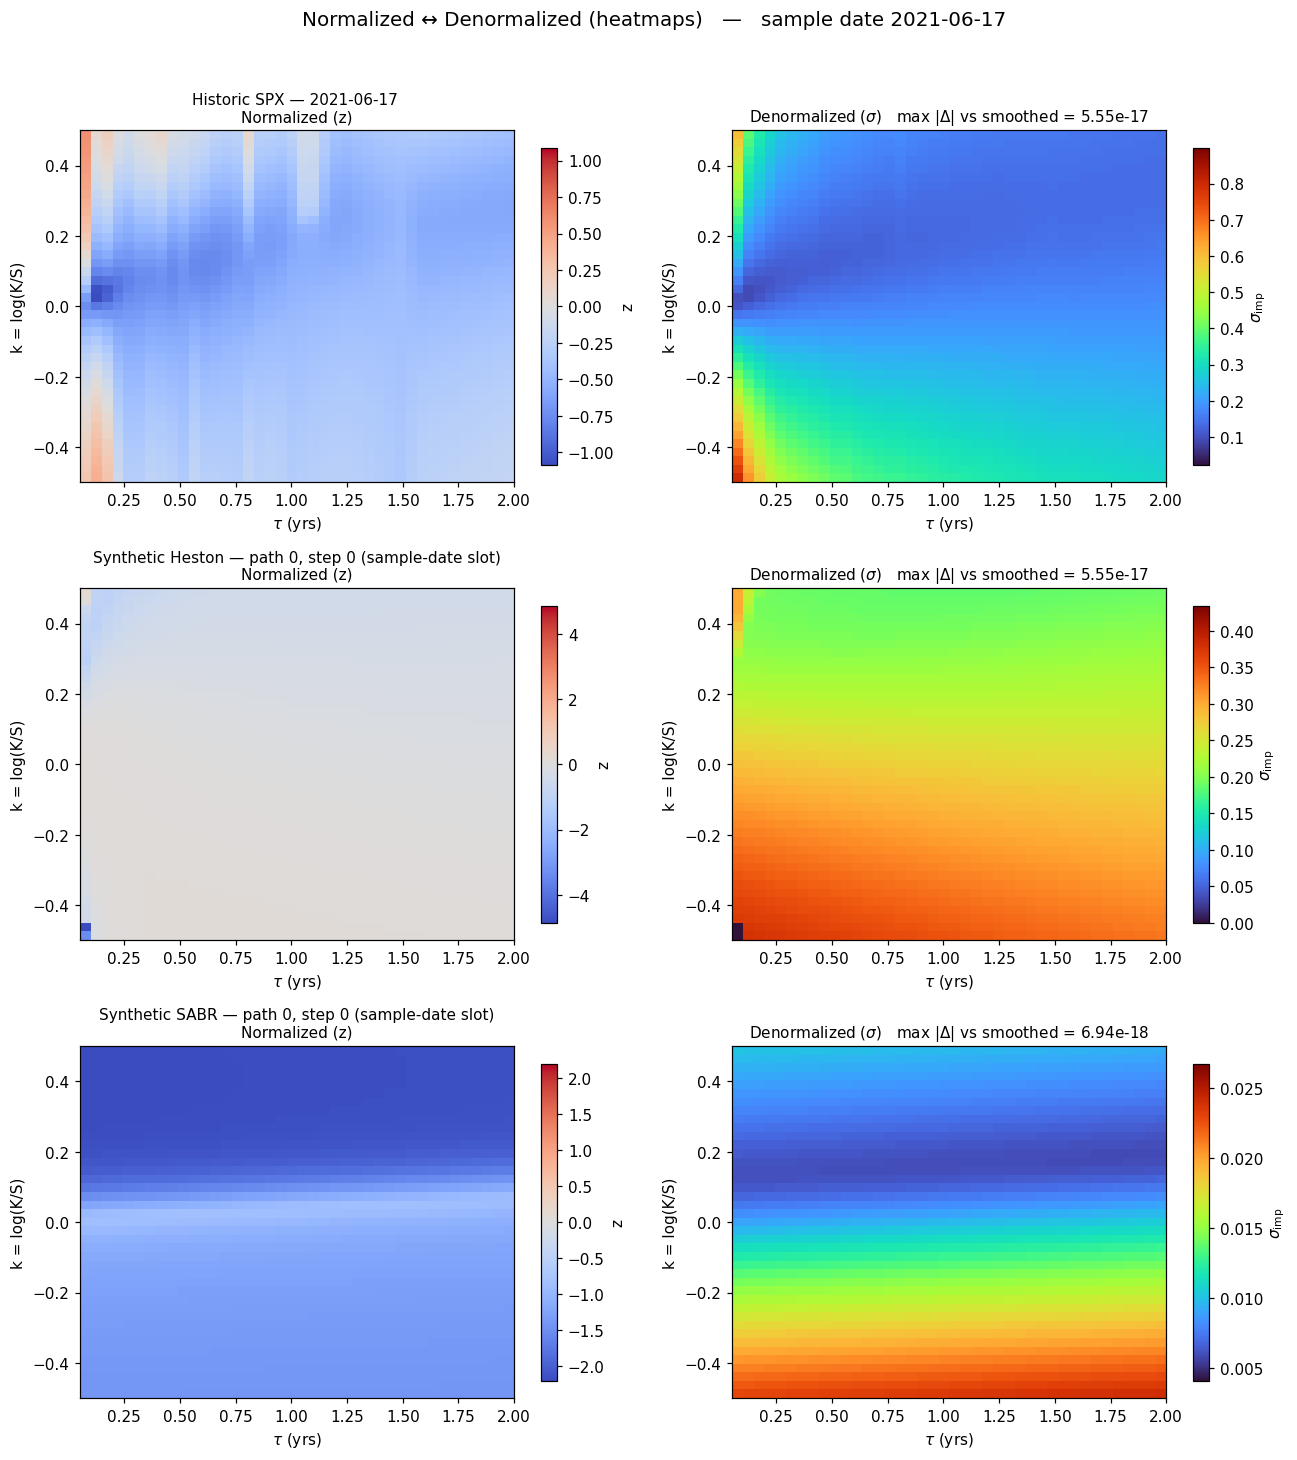

In [71]:
fig, axes = plt.subplots(len(bundles), 2, figsize=(12, 4.5 * len(bundles)))
if len(bundles) == 1:
    axes = np.atleast_2d(axes)
fig.suptitle(f"Normalized ↔ Denormalized (heatmaps)   —   sample date {SAMPLE_DATE.date()}", fontsize=13)

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax_left = axes[row, 0]
    im = ax_left.imshow(
        b.normalized, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_Z, vmin=z_vmin, vmax=z_vmax
    )
    fig.colorbar(im, ax=ax_left, shrink=0.9, label="z")
    ax_left.set_title(f"{b.title}\nNormalized (z)", fontsize=10)
    _label_heat(ax_left)

    ax_right = axes[row, 1]
    im = ax_right.imshow(
        b.denormalized, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax
    )
    fig.colorbar(im, ax=ax_right, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
    diff = float(np.nanmax(np.abs(b.denormalized - b.smoothed)))
    ax_right.set_title(f"Denormalized ($\\sigma$)   max |Δ| vs smoothed = {diff:.2e}", fontsize=10)
    _label_heat(ax_right)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()